# 01.6 — Extreme Precipitation Events & Tail Risk

Định lượng các phân vị cực trị và phân tích khoảng thời gian lặp lại của các sự kiện mưa lớn.


In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reconfigure encoding
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

# Path resolution
ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "src").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.data.loader import DataLoader, time_series_split
from src.eda.ExtremeEventAnalysis import ExtremeEventsAnalyzer

# 1. Nạp dữ liệu Train (Zero Leakage)
df = DataLoader().load_data()
train_df, _ = time_series_split(df)
print(f"📊 Phân tích Hiện tượng Cực đoan (Train Set: {len(train_df):,} ngày)")

# 2. Khởi tạo ExtremeEventsAnalyzer
extreme_analyzer = ExtremeEventsAnalyzer(train_df, target_col='Lượng mưa', date_col='Ngày')
extreme_results = extreme_analyzer.analyze()

thresholds = extreme_results.get('thresholds', {})
counts = extreme_results.get('extreme_counts', {})
p95 = float(thresholds.get('p95', train_df['Lượng mưa'].quantile(0.95)))
p99 = float(thresholds.get('p99', train_df['Lượng mưa'].quantile(0.99)))
p99_9 = float(thresholds.get('p99_9', train_df['Lượng mưa'].quantile(0.999)))
max_rain = float(train_df['Lượng mưa'].max())

print(f"\n⛈️ CÁC NGƯỠNG PHÂN VỊ CỰC ĐOAN:")
print(f"   • P95 (Mưa lớn):     {p95:.2f} mm/ngày ({counts.get('p95', 0)} ngày vượt ngưỡng)")
print(f"   • P99 (Mưa rất lớn): {p99:.2f} mm/ngày ({counts.get('p99', 0)} ngày vượt ngưỡng)")
print(f"   • P99.9 (Cực đoan):  {p99_9:.2f} mm/ngày ({counts.get('p99_9', 0)} ngày vượt ngưỡng)")
print(f"   • Lượng mưa ngày kỷ lục: {max_rain:.2f} mm")


📊 Phân tích Hiện tượng Cực đoan (Train Set: 7,060 ngày)

⛈️ COMPONENT 2: EXTREME EVENTS ANALYSIS
🔍 2.1 Extreme Events Definition
--------------------------------------------------
   📊 Extreme Event Thresholds:
      - 95th percentile: 17.19mm
      - 99th percentile: 34.16mm
      - 99.9th percentile: 61.59mm

   📈 Extreme Event Counts:
      - > 95th percentile: 352 events (4.99%)
      - > 99th percentile: 71 events (1.01%)
      - > 99.9th percentile: 8 events (0.11%)

🌪️ 2.2 Seasonal Patterns of Extreme Events
--------------------------------------------------
   📅 Peak extreme events month: 10

✅ EXTREME EVENTS ANALYSIS COMPLETED

⛈️ CÁC NGƯỠNG PHÂN VỊ CỰC ĐOAN:
   • P95 (Mưa lớn):     17.19 mm/ngày (352 ngày vượt ngưỡng)
   • P99 (Mưa rất lớn): 34.16 mm/ngày (71 ngày vượt ngưỡng)
   • P99.9 (Cực đoan):  61.59 mm/ngày (8 ngày vượt ngưỡng)
   • Lượng mưa ngày kỷ lục: 107.90 mm


In [2]:
# 3. Tính toán Recurrence Interval tuân thủ Rule 7 (Calendar Elapsed Time)
# RULE 7: date_series.diff().dt.days (chênh lệch ngày lịch thực tế)
extreme_p95_dates = train_df.loc[train_df['Lượng mưa'] > p95, 'Ngày'].sort_values()
extreme_p99_dates = train_df.loc[train_df['Lượng mưa'] > p99, 'Ngày'].sort_values()

# Chênh lệch lịch ngày thực tế:
recurrence_p95_days = extreme_p95_dates.diff().dt.days.dropna()
recurrence_p99_days = extreme_p99_dates.diff().dt.days.dropna()

mean_rec_p95 = float(recurrence_p95_days.mean())
median_rec_p95 = float(recurrence_p95_days.median())
mean_rec_p99 = float(recurrence_p99_days.mean())
median_rec_p99 = float(recurrence_p99_days.median())

print(f"\n⏳ CHU KỲ LẶP LẠI (CALENDAR ELAPSED TIME - RULE 7 VERIFIED):")
print(f"   • Chu kỳ lặp lại P95 (TB):       {mean_rec_p95:.1f} ngày lịch (Trung vị: {median_rec_p95:.1f} ngày)")
print(f"   • Chu kỳ lặp lại P99 (TB):       {mean_rec_p99:.1f} ngày lịch (Trung vị: {median_rec_p99:.1f} ngày)")
print(f"   • Phương pháp: date_series.diff().dt.days (Không dùng positional index difference)")



⏳ CHU KỲ LẶP LẠI (CALENDAR ELAPSED TIME - RULE 7 VERIFIED):
   • Chu kỳ lặp lại P95 (TB):       19.2 ngày lịch (Trung vị: 7.0 ngày)
   • Chu kỳ lặp lại P99 (TB):       96.4 ngày lịch (Trung vị: 38.0 ngày)
   • Phương pháp: date_series.diff().dt.days (Không dùng positional index difference)


🎨 Trực quan hóa Hiện tượng Cực đoan (4-panel):


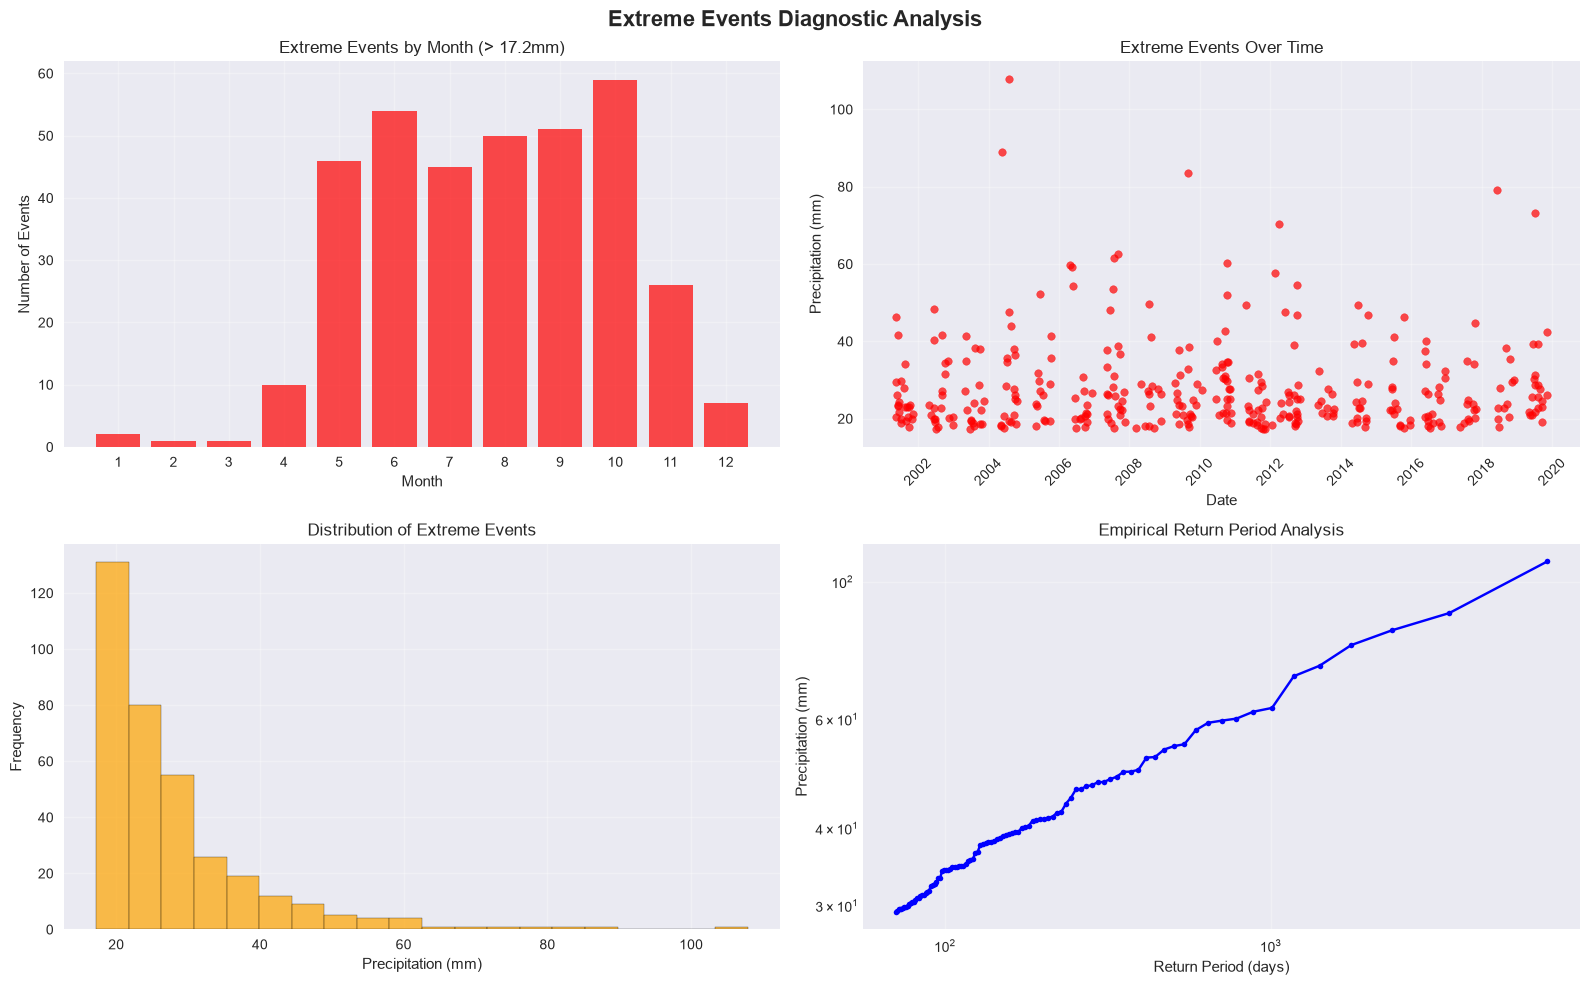

In [3]:
# 4. Trực quan hóa 4-Panel Extreme Events Analysis
print("🎨 Trực quan hóa Hiện tượng Cực đoan (4-panel):")
fig_extreme = extreme_analyzer.plot_extreme_events(return_fig=True)
plt.show()


In [4]:
# 5. Xuất Artifact extreme_events_report.json
OUTPUT_DIR = ROOT_DIR / "notebooks" / "eda" / "outputs"
DATA_OUTPUT_DIR = ROOT_DIR / "data" / "processed" / "eda_outputs"

extreme_artifact = {
    "thresholds": {
        "p95": round(p95, 2),
        "p99": round(p99, 2),
        "p99_9": round(p99_9, 2),
        "max_daily_mm": round(max_rain, 2)
    },
    "counts": {
        "p95": int(counts.get('p95', len(extreme_p95_dates))),
        "p99": int(counts.get('p99', len(extreme_p99_dates))),
        "p99_9": int(counts.get('p99_9', 0))
    },
    "recurrence_intervals_calendar_days": {
        "mean_p95_days": round(mean_rec_p95, 2),
        "median_p95_days": round(median_rec_p95, 2),
        "mean_p99_days": round(mean_rec_p99, 2),
        "median_p99_days": round(median_rec_p99, 2),
        "calculation_method": "date_series.diff().dt.days (Rule 7 compliant)"
    }
}

artifact_path = OUTPUT_DIR / "extreme_events_report.json"
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(extreme_artifact, f, indent=2, ensure_ascii=False)

with open(DATA_OUTPUT_DIR / "extreme_events_report.json", "w", encoding="utf-8") as f:
    json.dump(extreme_artifact, f, indent=2, ensure_ascii=False)

print(f"\n💾 Extreme events report exported to: {artifact_path}")
print(f"   • Ngưỡng P95: {p95:.2f} mm | P99: {p99:.2f} mm")
print(f"   • Chu kỳ lặp lại P95 TB: {mean_rec_p95:.1f} ngày lịch")



💾 Extreme events report exported to: D:\DS108_project\notebooks\eda\outputs\extreme_events_report.json
   • Ngưỡng P95: 17.19 mm | P99: 34.16 mm
   • Chu kỳ lặp lại P95 TB: 19.2 ngày lịch
